# Leçon 5: Python, calcul numérique avec numpy et scipy.
## Équations différentielles ordinaires, solution numérique.



Numpy est un module numérique et donne accès à plusieurs méthodes qui sont très utiles en calcul numérique. Les utilisateurs de calcul numérique sous matlab seront rapidement à l'aise avec les outils de numpy.

La solution des équations différentielles ordinaires avec les outils ODEXY de matlab ou avec ceux de numpy et scipy sont comparés dans ce qui suit:


 Voyons comment résoudre une cinétique enzymatique avec inhibition compétitive, il suffit d'écire les taux dans une fonction:
 <img src='MM.png'>

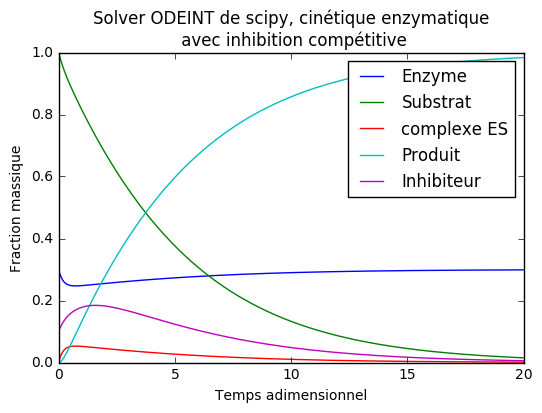

In [1]:
#
# Cinétique enzymatique avec inhibition compétitive
# premier exemple, cinétique ci-haut tirée de Wikipédia.
#
# coefficients arbitraires
#
def MM(C,t):
  ksf=1.
  ksr=1.
  kcat=3
  kif=0.8
  kir=0.5
  dC=np.array(len(C)*[0.0])
  dC[0]= ksr*C[2] - ksf*C[0]*C[1] + kcat*C[2]
  dC[1]= ksr*C[2] - ksf*C[0]*C[1]
  dC[2]=-ksr*C[2] + ksf*C[0]*C[1] - kcat*C[2]
  dC[3]=                            kcat*C[2]
  dC[4]=ksf*C[1]*C[0]-ksr*C[4]
  return dC
#
#
#
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#
y0=np.array([0.3 ,1.0,  0.0, 0.0 ,  0.1 ])
Fin=20
dt=0.02
t=np.arange(0,Fin,dt)        # on pourrait aussi utiliser linspace
X=odeint(MM,y0,t)
plt.plot(t,X)
plt.title('Solver ODEINT de scipy, cinétique enzymatique\n avec inhibition compétitive')
plt.legend(('Enzyme','Substrat','complexe ES','Produit','Inhibiteur'))
plt.ylabel('Fraction massique')
plt.xlabel('Temps adimensionnel')

*Autre exemple, un réacteur chimique de type CSTR dans lequel une réaction du deuxième ordre a lieu, on cherche la concentration en fonction du temps:*
$$\frac{dC_a}{dt}= \frac {Q}{V} (C_{ao} -C_{a}) -k_2 ^{'''} C_a ²$$
<img src='reacteur.png'>
La solution numérique de ce problème est similaire à l'exemple précédent

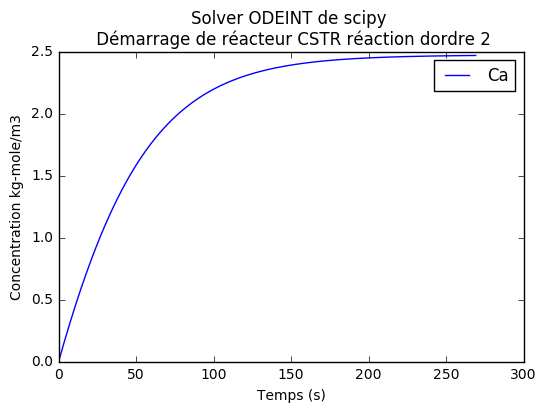

In [2]:
def der(C,t):
    dC=Q/V*(Cin-C)-k*C**2  
    return dC
#
#
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
Cin=4
V=.300
Q=.2/60.
k=Q/V/Cin  # constante arbitrairement égale au temps hydraul.
Fin=V/Q*3
dt=Fin/300
Ca0=0
t=np.arange(0,Fin,dt)        # on pourrait aussi utiliser linspace
C=odeint(der,Ca0,t)
plt.plot(t,C)
plt.title('Solver ODEINT de scipy \n Démarrage de réacteur CSTR réaction d''ordre 2')
plt.legend(('Ca',' '))
plt.ylabel('Concentration kg-mole/m3')
plt.xlabel('Temps (s)')